<a href="https://colab.research.google.com/github/aansheeagrwal/Machine-learning/blob/main/nyc_taxi_fare_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [214]:
!pip install numpy pandas jovian opendatasets scikit-learn xgboost --quiet

In [215]:
import jovian

In [216]:
jovian.commit()

[jovian] Detected Colab notebook...
[jovian] jovian.commit() is no longer required on Google Colab. If you ran this notebook from Jovian, 
then just save this file in Colab using Ctrl+S/Cmd+S and it will be updated on Jovian. 
Also, you can also delete this cell, it's no longer necessary.


In [217]:
import opendatasets as od

In [218]:
dataset_url = 'https://www.kaggle.com/c/new-york-city-taxi-fare-prediction/overview'

In [219]:
%%time
od.download(dataset_url)

Skipping, found downloaded files in "./new-york-city-taxi-fare-prediction" (use force=True to force download)
CPU times: user 0 ns, sys: 900 µs, total: 900 µs
Wall time: 814 µs


In [220]:
data_dir = './new-york-city-taxi-fare-prediction'

In [221]:
# List of files with size
!ls -lh {data_dir}

total 5.4G
-rw-r--r-- 1 root root  486 Apr 18 08:18 GCP-Coupons-Instructions.rtf
-rw-r--r-- 1 root root 336K Apr 18 08:18 sample_submission.csv
-rw-r--r-- 1 root root 960K Apr 18 08:18 test.csv
-rw-r--r-- 1 root root 5.4G Apr 18 08:19 train.csv


In [222]:
# Training set
!head {data_dir}/train.csv

key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
2009-06-15 17:26:21.0000001,4.5,2009-06-15 17:26:21 UTC,-73.844311,40.721319,-73.84161,40.712278,1
2010-01-05 16:52:16.0000002,16.9,2010-01-05 16:52:16 UTC,-74.016048,40.711303,-73.979268,40.782004,1
2011-08-18 00:35:00.00000049,5.7,2011-08-18 00:35:00 UTC,-73.982738,40.76127,-73.991242,40.750562,2
2012-04-21 04:30:42.0000001,7.7,2012-04-21 04:30:42 UTC,-73.98713,40.733143,-73.991567,40.758092,1
2010-03-09 07:51:00.000000135,5.3,2010-03-09 07:51:00 UTC,-73.968095,40.768008,-73.956655,40.783762,1
2011-01-06 09:50:45.0000002,12.1,2011-01-06 09:50:45 UTC,-74.000964,40.73163,-73.972892,40.758233,1
2012-11-20 20:35:00.0000001,7.5,2012-11-20 20:35:00 UTC,-73.980002,40.751662,-73.973802,40.764842,1
2012-01-04 17:22:00.00000081,16.5,2012-01-04 17:22:00 UTC,-73.9513,40.774138,-73.990095,40.751048,1
2012-12-03 13:10:00.000000125,9,2012-12-03 13:10:00 UTC,-74.006462,40.726713,-73.99

In [223]:
# Test set
!head {data_dir}/test.csv

key,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
2015-01-27 13:08:24.0000002,2015-01-27 13:08:24 UTC,-73.973320007324219,40.7638053894043,-73.981430053710938,40.74383544921875,1
2015-01-27 13:08:24.0000003,2015-01-27 13:08:24 UTC,-73.986862182617188,40.719383239746094,-73.998886108398438,40.739200592041016,1
2011-10-08 11:53:44.0000002,2011-10-08 11:53:44 UTC,-73.982524,40.75126,-73.979654,40.746139,1
2012-12-01 21:12:12.0000002,2012-12-01 21:12:12 UTC,-73.98116,40.767807,-73.990448,40.751635,1
2012-12-01 21:12:12.0000003,2012-12-01 21:12:12 UTC,-73.966046,40.789775,-73.988565,40.744427,1
2012-12-01 21:12:12.0000005,2012-12-01 21:12:12 UTC,-73.960983,40.765547,-73.979177,40.740053,1
2011-10-06 12:10:20.0000001,2011-10-06 12:10:20 UTC,-73.949013,40.773204,-73.959622,40.770893,1
2011-10-06 12:10:20.0000003,2011-10-06 12:10:20 UTC,-73.777282,40.646636,-73.985083,40.759368,1
2011-10-06 12:10:20.0000002,2011-10-06 12:10:20 UTC,-74.01409

In [224]:
# Sample submission file
!head {data_dir}/sample_submission.csv

key,fare_amount
2015-01-27 13:08:24.0000002,11.35
2015-01-27 13:08:24.0000003,11.35
2011-10-08 11:53:44.0000002,11.35
2012-12-01 21:12:12.0000002,11.35
2012-12-01 21:12:12.0000003,11.35
2012-12-01 21:12:12.0000005,11.35
2011-10-06 12:10:20.0000001,11.35
2011-10-06 12:10:20.0000003,11.35
2011-10-06 12:10:20.0000002,11.35


In [225]:
# No. of lines in training set
!wc -l {data_dir}/train.csv

55423856 ./new-york-city-taxi-fare-prediction/train.csv


In [226]:
# No. of lines in test set
!wc -l {data_dir}/test.csv

9914 ./new-york-city-taxi-fare-prediction/test.csv


In [227]:
# No. of lines in submission file
!wc -l {data_dir}/sample_submission.csv

9915 ./new-york-city-taxi-fare-prediction/sample_submission.csv


In [228]:
import pandas as pd
import random

In [230]:
# Change this
sample_frac = 0.01

In [231]:
%%time
selected_cols = 'fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count'.split(',')
dtypes = {
    'fare_amount': 'float32',
    'pickup_longitude': 'float32',
    'pickup_latitude': 'float32',
    'dropoff_longitude': 'float32',
    'passenger_count': 'float32'
}

def skip_row(row_idx):
    if row_idx == 0:
        return False
    return random.random() > sample_frac

random.seed(42)
df = pd.read_csv(data_dir+"/train.csv",
                 usecols=selected_cols,
                 dtype=dtypes,
                 parse_dates=['pickup_datetime'],
                 skiprows=skip_row)

CPU times: user 48.2 s, sys: 1.03 s, total: 49.2 s
Wall time: 51.2 s


In [232]:
df

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,4.0,2014-12-06 20:36:22+00:00,-73.979813,40.751904,-73.979446,40.755481,1.0
1,8.0,2013-01-17 17:22:00+00:00,0.000000,0.000000,0.000000,0.000000,2.0
2,8.9,2011-06-15 18:07:00+00:00,-73.996330,40.753223,-73.978897,40.766963,3.0
3,6.9,2009-12-14 12:33:00+00:00,-73.982430,40.745747,-73.982430,40.745747,1.0
4,7.0,2013-11-06 11:26:54+00:00,-73.959061,40.781059,-73.962059,40.768604,1.0
...,...,...,...,...,...,...,...
552445,45.0,2014-02-06 23:59:45+00:00,-73.973587,40.747669,-73.999916,40.602893,1.0
552446,22.5,2015-01-05 15:29:08+00:00,-73.935928,40.799656,-73.985710,40.726952,2.0
552447,4.5,2013-02-17 22:27:00+00:00,-73.992531,40.748619,-73.998436,40.740142,1.0
552448,14.5,2013-01-27 12:41:00+00:00,-74.012115,40.706635,-73.988724,40.756217,1.0


In [233]:
test_df = pd.read_csv(data_dir+'/test.csv', dtype=dtypes, parse_dates=['pickup_datetime'])

In [234]:
test_df

,key,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,2015-01-27 13:08:24.0000002,2015-01-27 13:08:24+00:00,-73.973320,40.763805,-73.981430,40.743835,1.0
1,2015-01-27 13:08:24.0000003,2015-01-27 13:08:24+00:00,-73.986862,40.719383,-73.998886,40.739201,1.0
2,2011-10-08 11:53:44.0000002,2011-10-08 11:53:44+00:00,-73.982521,40.751259,-73.979652,40.746139,1.0
3,2012-12-01 21:12:12.0000002,2012-12-01 21:12:12+00:00,-73.981163,40.767807,-73.990448,40.751635,1.0
4,2012-12-01 21:12:12.0000003,2012-12-01 21:12:12+00:00,-73.966049,40.789776,-73.988564,40.744427,1.0
...,...,...,...,...,...,...,...
9909,2015-05-10 12:37:51.0000002,2015-05-10 12:37:51+00:00,-73.968124,40.796997,-73.955643,40.780388,6.0
9910,2015-01-12 17:05:51.0000001,2015-01-12 17:05:51+00:00,-73.945511,40.803600,-73.960213,40.776371,6.0
9911,2015-04-19 20:44:15.0000001,2015-04-19 20:44:15+00:00,-73.991600,40.726608,-73.789742,40.647011,6.0
9912,2015-01-31 01:05:19.0000005,2015-01-31 01:05:19+00:00,-73.985573,40.735432,-73.939178,40.801731,6.0


In [235]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 552450 entries, 0 to 552449
Data columns (total 7 columns):
 #   Column             Non-Null Count   Dtype              
---  ------             --------------   -----              
 0   fare_amount        552450 non-null  float32            
 1   pickup_datetime    552450 non-null  datetime64[ns, UTC]
 2   pickup_longitude   552450 non-null  float32            
 3   pickup_latitude    552450 non-null  float32            
 4   dropoff_longitude  552450 non-null  float32            
 5   dropoff_latitude   552450 non-null  float64            
 6   passenger_count    552450 non-null  float32            
dtypes: datetime64[ns, UTC](1), float32(5), float64(1)
memory usage: 19.0 MB


In [236]:
df.describe()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,552450.000000,552450.000000,552450.000000,552450.000000,552450.000000,552450.000000
mean,11.354059,-72.497063,39.910500,-72.504326,39.934257,1.684983
std,9.810809,11.622035,8.041162,12.065184,9.255058,1.341986
min,-52.000000,-1183.362793,-3084.490234,-3356.729736,-2073.150613,0.000000
25%,6.000000,-73.992020,40.734875,-73.991425,40.733988,1.000000
50%,8.500000,-73.981819,40.752621,-73.980179,40.753102,1.000000
75%,12.500000,-73.967155,40.767036,-73.963737,40.768060,2.000000
max,499.000000,2420.209473,404.983337,2467.752686,3351.403027,208.000000


In [237]:
df.pickup_datetime.min(), df.pickup_datetime.max()

(Timestamp('2009-01-01 00:11:46+0000', tz='UTC'),
 Timestamp('2015-06-30 23:59:54+0000', tz='UTC'))

In [238]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9914 entries, 0 to 9913
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype              
---  ------             --------------  -----              
 0   key                9914 non-null   object             
 1   pickup_datetime    9914 non-null   datetime64[ns, UTC]
 2   pickup_longitude   9914 non-null   float32            
 3   pickup_latitude    9914 non-null   float32            
 4   dropoff_longitude  9914 non-null   float32            
 5   dropoff_latitude   9914 non-null   float64            
 6   passenger_count    9914 non-null   float32            
dtypes: datetime64[ns, UTC](1), float32(4), float64(1), object(1)
memory usage: 387.4+ KB


In [239]:
test_df.describe()

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,9914.000000,9914.000000,9914.000000,9914.000000,9914.000000
mean,-73.974716,40.751041,-73.973656,40.751743,1.671273
std,0.042799,0.033542,0.039093,0.035435,1.278756
min,-74.252190,40.573143,-74.263245,40.568973,1.000000
25%,-73.992500,40.736125,-73.991249,40.735254,1.000000
50%,-73.982327,40.753052,-73.980015,40.754065,1.000000
75%,-73.968012,40.767113,-73.964062,40.768757,2.000000
max,-72.986534,41.709557,-72.990967,41.696683,6.000000


In [240]:
test_df.pickup_datetime.min(), test_df.pickup_datetime.max()

(Timestamp('2009-01-01 11:04:24+0000', tz='UTC'),
 Timestamp('2015-06-30 20:03:50+0000', tz='UTC'))

In [241]:
from sklearn.model_selection import train_test_split

In [242]:
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

In [243]:
len(train_df), len(val_df)

(441960, 110490)

In [244]:
train_df = train_df.dropna()
val_df = val_df.dropna()

In [245]:
df.columns

Index(['fare_amount', 'pickup_datetime', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'passenger_count'],
      dtype='object')

In [246]:
input_cols = ['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'passenger_count']

In [247]:
target_col = 'fare_amount'

In [248]:
train_inputs = train_df[input_cols]

In [249]:
train_targets = train_df[target_col]

In [250]:
train_inputs

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
353352,-73.993652,40.741543,-73.977974,40.742352,4.0
360070,-73.993805,40.724579,-73.993805,40.724577,1.0
372609,-73.959160,40.780750,-73.969116,40.761231,1.0
550895,-73.952187,40.783951,-73.978645,40.772603,1.0
444151,-73.977112,40.746834,-73.991104,40.750403,2.0
...,...,...,...,...,...
110268,-73.987152,40.750633,-73.979073,40.763167,1.0
259178,-73.972656,40.764042,-74.013176,40.707841,2.0
365838,-73.991982,40.749767,-73.989845,40.720552,3.0
131932,-73.969055,40.761398,-73.990814,40.751327,1.0


In [252]:
train_targets

,fare_amount
353352,6.0
360070,3.7
372609,10.0
550895,8.9
444151,7.3
...,...
110268,9.3
259178,18.5
365838,10.1
131932,10.9


In [253]:
val_inputs = val_df[input_cols]

In [254]:
val_targets = val_df[target_col]

In [255]:
val_inputs

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
15971,-73.995834,40.759190,-73.973679,40.739086,1.0
149839,-73.977386,40.738335,-73.976143,40.751204,1.0
515867,-73.983910,40.749470,-73.787170,40.646643,1.0
90307,-73.790794,40.643463,-73.972252,40.690180,1.0
287032,-73.976593,40.761944,-73.991463,40.750309,2.0
...,...,...,...,...,...
467556,-73.968567,40.761238,-73.983406,40.750020,3.0
19482,-73.986725,40.755920,-73.985855,40.731170,1.0
186063,0.000000,0.000000,0.000000,0.000000,1.0
382260,-73.980057,40.760334,-73.872589,40.774298,1.0


In [256]:
val_targets

,fare_amount
15971,14.000000
149839,6.500000
515867,49.570000
90307,49.700001
287032,8.500000
...,...
467556,6.100000
19482,7.300000
186063,4.500000
382260,32.900002


In [257]:
test_inputs = test_df[input_cols]

In [258]:
test_inputs

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,-73.973320,40.763805,-73.981430,40.743835,1.0
1,-73.986862,40.719383,-73.998886,40.739201,1.0
2,-73.982521,40.751259,-73.979652,40.746139,1.0
3,-73.981163,40.767807,-73.990448,40.751635,1.0
4,-73.966049,40.789776,-73.988564,40.744427,1.0
...,...,...,...,...,...
9909,-73.968124,40.796997,-73.955643,40.780388,6.0
9910,-73.945511,40.803600,-73.960213,40.776371,6.0
9911,-73.991600,40.726608,-73.789742,40.647011,6.0
9912,-73.985573,40.735432,-73.939178,40.801731,6.0


In [259]:
import numpy as np

In [260]:
class MeanRegressor():
    def fit(self, inputs, targets):
        self.mean = targets.mean()

    def predict(self, inputs):
        return np.full(inputs.shape[0], self.mean)

In [261]:
mean_model = MeanRegressor()

In [262]:
mean_model.fit(train_inputs, train_targets)

In [263]:
mean_model.mean

np.float32(11.354714)

In [264]:
train_preds = mean_model.predict(train_inputs)

In [265]:
train_preds

array([11.354714, 11.354714, 11.354714, ..., 11.354714, 11.354714,
       11.354714], dtype=float32)

In [266]:
val_preds = mean_model.predict(val_inputs)

In [267]:
val_preds

array([11.354714, 11.354714, 11.354714, ..., 11.354714, 11.354714,
       11.354714], dtype=float32)

In [268]:
from sklearn.metrics import mean_squared_error

In [269]:
train_mse = mean_squared_error(train_targets, train_preds)
train_rmse = np.sqrt(train_mse)

In [270]:
train_rmse

np.float64(9.789781840838485)

In [271]:
val_mse = mean_squared_error(val_targets, val_preds)
val_rmse = np.sqrt(val_mse)

In [273]:
val_rmse

np.float64(9.89995425435296)

In [274]:
from sklearn.linear_model import LinearRegression

In [275]:
linreg_model = LinearRegression()

In [276]:
linreg_model.fit(train_inputs, train_targets)

LinearRegression()

In [277]:
train_preds = linreg_model.predict(train_inputs)
train_preds

array([11.54623682, 11.28460949, 11.28413941, ..., 11.45891673,
       11.28428005, 11.28444733])

In [278]:
val_preds = linreg_model.predict(val_inputs)
val_preds

array([11.28432795, 11.28449549, 11.28478054, ..., 11.80449938,
       11.28443343, 11.28413233])

In [279]:
train_mse = mean_squared_error(train_targets, train_preds)
train_rmse = np.sqrt(train_mse)

In [280]:
val_mse = mean_squared_error(val_targets, val_preds)
val_rmse = np.sqrt(val_mse)

In [281]:
test_inputs

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,-73.973320,40.763805,-73.981430,40.743835,1.0
1,-73.986862,40.719383,-73.998886,40.739201,1.0
2,-73.982521,40.751259,-73.979652,40.746139,1.0
3,-73.981163,40.767807,-73.990448,40.751635,1.0
4,-73.966049,40.789776,-73.988564,40.744427,1.0
...,...,...,...,...,...
9909,-73.968124,40.796997,-73.955643,40.780388,6.0
9910,-73.945511,40.803600,-73.960213,40.776371,6.0
9911,-73.991600,40.726608,-73.789742,40.647011,6.0
9912,-73.985573,40.735432,-73.939178,40.801731,6.0


In [282]:
test_preds = linreg_model.predict(test_inputs)

In [283]:
submission_df = pd.read_csv(data_dir+'/sample_submission.csv')

In [284]:
submission_df

,key,fare_amount
0,2015-01-27 13:08:24.0000002,11.35
1,2015-01-27 13:08:24.0000003,11.35
2,2011-10-08 11:53:44.0000002,11.35
3,2012-12-01 21:12:12.0000002,11.35
4,2012-12-01 21:12:12.0000003,11.35
...,...,...
9909,2015-05-10 12:37:51.0000002,11.35
9910,2015-01-12 17:05:51.0000001,11.35
9911,2015-04-19 20:44:15.0000001,11.35
9912,2015-01-31 01:05:19.0000005,11.35


In [332]:
def generate_submission(test_preds, fname):
    sub_df = pd.read_csv(data_dir+'/sample_submission.csv')
    sub_df['fare_amount'] = test_preds
    sub_df.to_csv(fname, index=None)

In [333]:
generate_submission(test_preds, 'linreg_submission.csv')

In [334]:
def add_dateparts(df, col):
  df[col + '_year'] = df[col].dt.year
  df[col + '_month'] = df[col].dt.month
  df[col + '_day'] = df[col].dt.day
  df[col + '_weekday'] = df[col].dt.weekday
  df[col + '_hour'] = df[col].dt.hour

In [335]:
add_dateparts(train_df, 'pickup_datetime')

<ipython-input-334-41c4d2475669>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col + '_year'] = df[col].dt.year
<ipython-input-334-41c4d2475669>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col + '_month'] = df[col].dt.month
<ipython-input-334-41c4d2475669>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_g

In [336]:
add_dateparts(val_df, 'pickup_datetime')

<ipython-input-334-41c4d2475669>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col + '_year'] = df[col].dt.year
<ipython-input-334-41c4d2475669>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col + '_month'] = df[col].dt.month
<ipython-input-334-41c4d2475669>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_g

In [349]:
add_dateparts(test_df, 'pickup_datetime')

In [350]:
import numpy as np

def haversine_np(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    km = 6367 * c
    return km

In [351]:
def add_trip_distance(df):
    df['trip_distance'] = haversine_np(df['pickup_longitude'], df['pickup_latitude'], df['dropoff_longitude'], df['dropoff_latitude'])




In [352]:
add_trip_distance(train_df)

<ipython-input-351-2d392fdd7308>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['trip_distance'] = haversine_np(df['pickup_longitude'], df['pickup_latitude'], df['dropoff_longitude'], df['dropoff_latitude'])


In [347]:
add_trip_distance(val_df)

<ipython-input-345-2d392fdd7308>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['trip_distance'] = haversine_np(df['pickup_longitude'], df['pickup_latitude'], df['dropoff_longitude'], df['dropoff_latitude'])


In [353]:
add_trip_distance(test_df)

In [354]:
jfk_lonlat = -73.7781, 40.6413
lga_lonlat = -73.8740, 40.7769
ewr_lonlat = -74.1745, 40.6895
met_lonlat = -73.9632, 40.7794
wtc_lonlat = -74.0099, 40.7126

In [355]:
# Function to add drop distance in data from landmark
def add_landmark_dropoff_distance(df, landmark_name, landmark_lonlat):
    lon, lat = landmark_lonlat
    df[landmark_name + '_drop_distance'] = haversine_np(lon, lat, df['dropoff_longitude'], df['dropoff_latitude'])

In [356]:
def add_landmarks(a_df):
  landmarks = [('jfk', jfk_lonlat), ('lga', lga_lonlat), ('ewr', ewr_lonlat), ('met', met_lonlat), ('wtc', wtc_lonlat)]
  for name, lonlat in landmarks:
    add_landmark_dropoff_distance(a_df, name, lonlat)

In [357]:
add_landmarks(train_df)

<ipython-input-355-f2e6dcdf79ee>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[landmark_name + '_drop_distance'] = haversine_np(lon, lat, df['dropoff_longitude'], df['dropoff_latitude'])
<ipython-input-355-f2e6dcdf79ee>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[landmark_name + '_drop_distance'] = haversine_np(lon, lat, df['dropoff_longitude'], df['dropoff_latitude'])
<ipython-input-355-f2e6dcdf79ee>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

In [358]:
add_landmarks(val_df)

<ipython-input-355-f2e6dcdf79ee>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[landmark_name + '_drop_distance'] = haversine_np(lon, lat, df['dropoff_longitude'], df['dropoff_latitude'])
<ipython-input-355-f2e6dcdf79ee>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[landmark_name + '_drop_distance'] = haversine_np(lon, lat, df['dropoff_longitude'], df['dropoff_latitude'])
<ipython-input-355-f2e6dcdf79ee>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

In [359]:
add_landmarks(test_df)

In [360]:
test_df

,key,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,pickup_datetime_year,pickup_datetime_month,pickup_datetime_day,...,jfk_dropoff_distance,lga_dropoff_distance,ewr_dropoff_distance,met_dropoff_distance,wtc_dropoff_distance,jfk_drop_distance,lga_drop_distance,ewr_drop_distance,met_drop_distance,wtc_drop_distance
0,2015-01-27 13:08:24.0000002,2015-01-27 13:08:24+00:00,-73.973320,40.763805,-73.981430,40.743835,1.0,2015,1,27,...,20.574949,9.760151,17.346891,4.239318,4.218800,20.574949,9.760151,17.346891,4.239318,4.218800
1,2015-01-27 13:08:24.0000003,2015-01-27 13:08:24+00:00,-73.986862,40.719383,-73.998886,40.739201,1.0,2015,1,27,...,21.550981,11.315998,15.789650,5.382910,3.098180,21.550981,11.315998,15.789650,5.382910,3.098180
2,2011-10-08 11:53:44.0000002,2011-10-08 11:53:44+00:00,-73.982521,40.751259,-73.979652,40.746139,1.0,2011,10,8,...,20.594007,9.526878,17.576952,3.946866,4.514444,20.594007,9.526878,17.576952,3.946866,4.514444
3,2012-12-01 21:12:12.0000002,2012-12-01 21:12:12+00:00,-73.981163,40.767807,-73.990448,40.751635,1.0,2012,12,1,...,21.689160,10.195201,16.969532,3.844222,4.636742,21.689160,10.195201,16.969532,3.844222,4.636742
4,2012-12-01 21:12:12.0000003,2012-12-01 21:12:12+00:00,-73.966049,40.789776,-73.988564,40.744427,1.0,2012,12,1,...,21.113870,10.295947,16.808312,4.434000,3.967057,21.113870,10.295947,16.808312,4.434000,3.967057
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9909,2015-05-10 12:37:51.0000002,2015-05-10 12:37:51+00:00,-73.968124,40.796997,-73.955643,40.780388,6.0,2015,5,10,...,21.507015,6.880891,21.014938,0.645636,8.809757,21.507015,6.880891,21.014938,0.645636,8.809757
9910,2015-01-12 17:05:51.0000001,2015-01-12 17:05:51+00:00,-73.945511,40.803600,-73.960213,40.776371,6.0,2015,1,12,...,21.462229,7.254930,20.464521,0.420324,8.229248,21.462229,7.254930,20.464521,0.420324,8.229248
9911,2015-04-19 20:44:15.0000001,2015-04-19 20:44:15+00:00,-73.991600,40.726608,-73.789742,40.647011,6.0,2015,4,19,...,1.169152,16.084441,32.772347,20.734211,19.933692,1.169152,16.084441,32.772347,20.734211,19.933692
9912,2015-01-31 01:05:19.0000005,2015-01-31 01:05:19+00:00,-73.985573,40.735432,-73.939178,40.801731,6.0,2015,1,31,...,22.402436,6.138515,23.410822,3.200773,11.556237,22.402436,6.138515,23.410822,3.200773,11.556237


In [361]:
test_df.describe()

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,pickup_datetime_year,pickup_datetime_month,pickup_datetime_day,pickup_datetime_weekday,pickup_datetime_hour,...,jfk_dropoff_distance,lga_dropoff_distance,ewr_dropoff_distance,met_dropoff_distance,wtc_dropoff_distance,jfk_drop_distance,lga_drop_distance,ewr_drop_distance,met_drop_distance,wtc_drop_distance
count,9914.000000,9914.000000,9914.000000,9914.000000,9914.000000,9914.000000,9914.000000,9914.000000,9914.000000,9914.000000,...,9914.000000,9914.000000,9914.000000,9914.000000,9914.000000,9914.000000,9914.000000,9914.000000,9914.000000,9914.000000
mean,-73.974716,40.751041,-73.973656,40.751743,1.671273,2011.815816,6.857979,16.194170,2.852834,13.467420,...,20.916707,9.675209,18.546655,4.512975,6.037621,20.916707,9.675209,18.546655,4.512975,6.037621
std,0.042799,0.033542,0.039093,0.035435,1.278756,1.803347,3.353272,8.838482,1.994451,6.868584,...,3.303942,3.295656,4.035818,4.018438,4.252537,3.303942,3.295656,4.035818,4.018438,4.252537
min,-74.252190,40.573143,-74.263245,40.568973,1.000000,2009.000000,1.000000,1.000000,0.000000,0.000000,...,0.402057,0.285510,0.284706,0.085728,0.040386,0.402057,0.285510,0.284706,0.085728,0.040386
25%,-73.992500,40.736125,-73.991249,40.735254,1.000000,2010.000000,4.000000,9.000000,1.000000,8.000000,...,20.513366,8.311562,16.520468,2.126326,3.669914,20.513366,8.311562,16.520468,2.126326,3.669914
50%,-73.982327,40.753052,-73.980015,40.754065,1.000000,2012.000000,7.000000,16.000000,3.000000,15.000000,...,21.181394,9.477792,18.024364,3.698360,5.541418,21.181394,9.477792,18.024364,3.698360,5.541418
75%,-73.968012,40.767113,-73.964062,40.768757,2.000000,2014.000000,10.000000,25.000000,5.000000,19.000000,...,21.909781,10.965471,19.880521,5.922760,7.757408,21.909781,10.965471,19.880521,5.922760,7.757408
max,-72.986534,41.709557,-72.990967,41.696683,6.000000,2015.000000,12.000000,31.000000,6.000000,23.000000,...,134.497657,126.062486,149.400789,130.347048,138.619454,134.497657,126.062486,149.400789,130.347048,138.619454


In [362]:
def remove_outliers(df):
  return df[(df['fare_amount'] >= 1.) &
            (df['fare_amount'] <= 500.) &
            (df['pickup_longitude'] >= -75) &
            (df['pickup_longitude'] <= -72) &
            (df['dropoff_longitude'] >= -75) &
            (df['dropoff_longitude'] <= -72) &
            (df['pickup_latitude'] >= 40) &
            (df['pickup_latitude'] <= 42) &
            (df['dropoff_latitude'] >=40) &
            (df['dropoff_latitude'] <=42) &
            (df['passenger_count'] >= 1) &
            (df['passenger_count'] <= 6)]

In [363]:
train_df = remove_outliers(train_df)

In [364]:
val_df = remove_outliers(val_df)

In [365]:
train_df.to_parquet('train.parquet')

In [366]:
val_df.to_parquet('val.parquet')

In [367]:
train_df.columns

Index(['fare_amount', 'pickup_datetime', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'passenger_count',
       'pickup_datetime_year', 'pickup_datetime_month', 'pickup_datetime_day',
       'pickup_datetime_weekday', 'pickup_datetime_hour', 'trip_distance',
       'jfk_dropoff_distance', 'lga_dropoff_distance', 'ewr_dropoff_distance',
       'met_dropoff_distance', 'wtc_dropoff_distance', 'jfk_drop_distance',
       'lga_drop_distance', 'ewr_drop_distance', 'met_drop_distance',
       'wtc_drop_distance'],
      dtype='object')

In [368]:
input_cols =['pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'passenger_count',
       'pickup_datetime_year', 'pickup_datetime_month', 'pickup_datetime_day',
       'pickup_datetime_weekday', 'pickup_datetime_hour', 'trip_distance',
       'jfk_dropoff_distance', 'lga_dropoff_distance', 'ewr_dropoff_distance',
       'met_dropoff_distance', 'wtc_dropoff_distance']

In [369]:
target_col = 'fare_amount'

In [370]:
train_inputs = train_df[input_cols]
train_targets = train_df[target_col]

In [371]:
val_inputs = val_df[input_cols]
val_targets = val_df[target_col]


In [372]:
test_inputs = test_df[input_cols]

In [373]:
def evaluate(model):
    train_preds = model.predict(train_inputs)
    train_rmse = rmse(train_targets, train_preds)

    val_preds = model.predict(val_inputs)
    val_rmse = rmse(val_targets, val_preds)
    return train_rmse, val_rmse, train_preds, val_preds


In [374]:
from sklearn.metrics import mean_squared_error
import numpy as np

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


In [375]:
from sklearn.linear_model import Ridge

In [376]:
model1 = Ridge(random_state=42)

In [377]:
model1.fit(train_inputs, train_targets)

Ridge(random_state=42)

In [378]:
evaluate(model1)

(np.float64(5.049312855022609),
 np.float64(5.217863164084476),
 array([ 8.12926895,  4.11625204,  8.75052428, ..., 10.47189549,
         8.23053339, 10.58672574]),
 array([10.91970437,  6.20497332, 46.21797207, ...,  8.04644756,
        25.56873019,  8.45308844]))

In [379]:
train_inputs.shape

(431098, 16)

In [386]:
def predict_and_submit(model, test_inputs, test_keys, filename):
    test_preds = model.predict(test_inputs)

    submission_df = pd.DataFrame({
        'key': test_keys,
        'fare_amount': test_preds
    })

    submission_df.to_csv(filename, index=False)
    print(f"✅ Submission saved as '{filename}' with 'key' and 'fare_amount'.")


In [387]:
feature_columns = list(train_inputs.columns)  # if not already defined
test_inputs = test_df[feature_columns]
test_keys = test_df['key']



In [388]:
predict_and_submit(model1, test_inputs, test_keys, 'ridge_submission.csv')


✅ Submission saved as 'ridge_submission.csv' with 'key' and 'fare_amount'.


In [389]:
from sklearn.ensemble import RandomForestRegressor

In [390]:
model2 = RandomForestRegressor(random_state=42, n_jobs=-1, max_depth=10, n_estimators=100)

In [391]:
%%time
model2.fit(train_inputs, train_targets)

CPU times: user 11min 6s, sys: 1.34 s, total: 11min 8s
Wall time: 7min 3s


RandomForestRegressor(max_depth=10, n_jobs=-1, random_state=42)

In [393]:
evaluate(model2)

(np.float64(3.5903984869221874),
 np.float64(4.1605787606818545),
 array([ 6.99156456,  9.20634281,  9.08617526, ..., 10.42907294,
         7.78595196, 10.4215362 ]),
 array([12.61176441,  6.14725291, 47.31186835, ...,  8.37080446,
        29.24303523,  8.22677944]))

In [394]:
predict_and_submit(model2, test_inputs, test_keys, 'rf_submission.csv')

✅ Submission saved as 'rf_submission.csv' with 'key' and 'fare_amount'.


In [395]:
from xgboost import XGBRegressor

In [400]:
model3 = XGBRegressor(
    max_depth=5,
    objective='reg:squarederror',
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

In [401]:
model3.fit(train_inputs, train_targets)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=200, n_jobs=-1,
             num_parallel_tree=None, random_state=42, ...)

In [402]:
evaluate(model3)

(np.float64(3.1406474705741534),
 np.float64(4.013989067074152),
 array([ 6.9159355,  7.990122 ,  9.990166 , ..., 12.167468 ,  9.520481 ,
         9.675571 ], dtype=float32),
 array([15.389366 ,  5.6744556, 49.11096  , ...,  7.7801576, 30.395191 ,
         8.314276 ], dtype=float32))

In [405]:
predict_and_submit(model3, test_inputs, test_keys, 'xgb_submission.csv')


✅ Submission saved as 'xgb_submission.csv' with 'key' and 'fare_amount'.


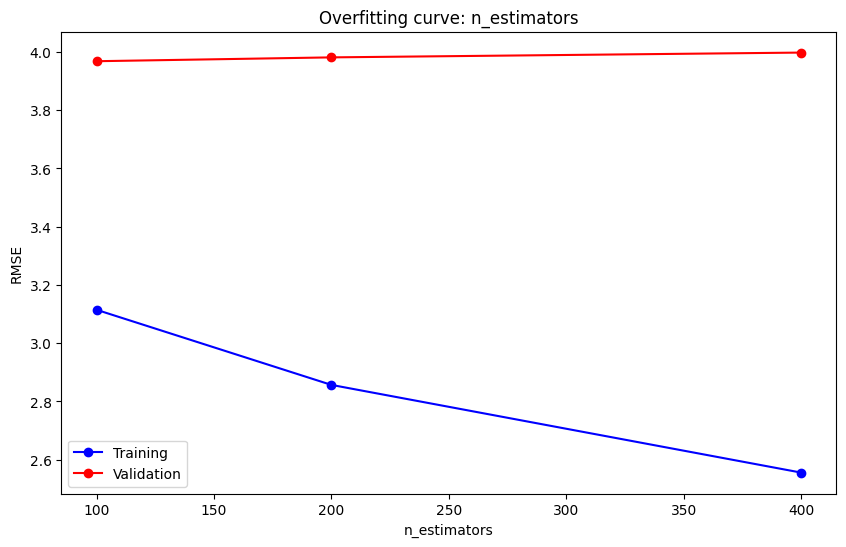

In [477]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

def test_params(ModelClass, train_inputs, train_targets, val_inputs, val_targets, **params):
    # Fit the model using the provided parameters
    model = ModelClass(**params).fit(train_inputs, train_targets)

    # Calculate RMSE for training and validation sets using mean_squared_error with squared=False
    train_rmse = rmse(train_targets, model.predict(train_inputs))
    val_rmse = rmse(val_targets, model.predict(val_inputs))

    return train_rmse, val_rmse

def test_params_plot(ModelClass, param_name, param_values, train_inputs, train_targets, val_inputs, val_targets, **other_params):
    train_errors, val_errors = [], []

    # Iterate through each value for the given parameter
    for value in param_values:
        # Set the current value for the parameter being tested
        params = dict(other_params)
        params[param_name] = value

        # Call the test_params function with the correct arguments
        train_rmse, val_rmse = test_params(ModelClass, train_inputs, train_targets, val_inputs, val_targets, **params)

        # Append the RMSE values to the lists
        train_errors.append(train_rmse)
        val_errors.append(val_rmse)

    # Plot the overfitting curve (train vs. validation RMSE)
    plt.figure(figsize=(10,6))
    plt.title('Overfitting curve: ' + param_name)
    plt.plot(param_values, train_errors, 'b-o')
    plt.plot(param_values, val_errors, 'r-o')
    plt.xlabel(param_name)
    plt.ylabel('RMSE')
    plt.legend(['Training', 'Validation'])
    plt.show()

# Usage example (ensure `train_inputs`, `train_targets`, `val_inputs`, `val_targets`, and `best_params` are defined)
test_params_plot(
    XGBRegressor,
    'n_estimators',
    [100, 200, 400],
    train_inputs=train_inputs,
    train_targets=train_targets,
    val_inputs=val_inputs,
    val_targets=val_targets,
    **best_params
)


In [483]:
best_params['n_estimators'] = 200

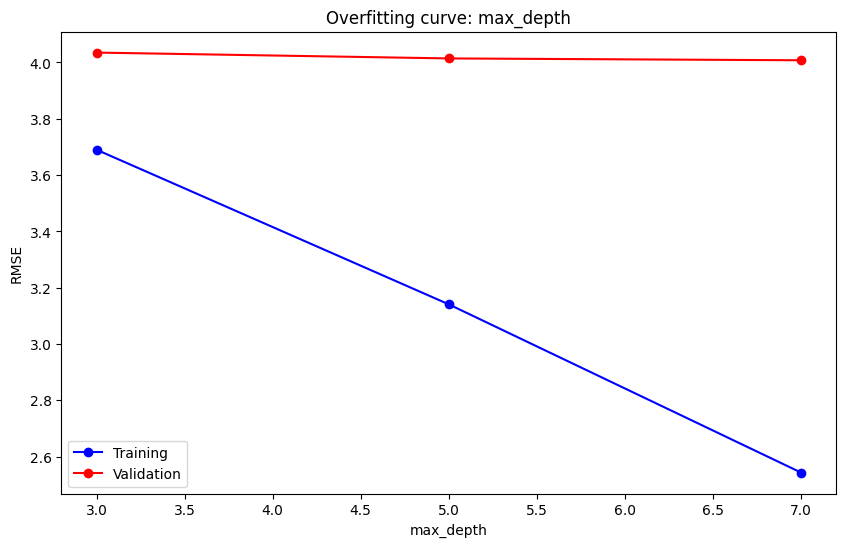

In [482]:
test_params_plot(XGBRegressor, 'max_depth', [3, 5, 7], train_inputs, train_targets, val_inputs, val_targets, **best_params)


In [484]:
best_params['learning_rate'] = 0.25


In [485]:
xgb_model_final = XGBRegressor(objective='reg:squarederror', n_jobs=-1, random_state=42,
                               n_estimators=500, max_depth=5, learning_rate=0.1,
                               subsample=0.8, colsample_bytree=0.8)


In [486]:
%%time
xgb_model_final.fit(train_inputs, train_targets)


CPU times: user 26.5 s, sys: 68.6 ms, total: 26.6 s
Wall time: 20.9 s


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=500, n_jobs=-1,
             num_parallel_tree=None, random_state=42, ...)

In [487]:
evaluate(xgb_model_final)


(np.float64(3.177574561660146),
 np.float64(3.9743583881134787),
 array([ 6.40014 ,  7.826713, 10.090213, ..., 11.700136,  9.153927,
        10.020915], dtype=float32),
 array([14.793883 ,  6.1466355, 48.299778 , ...,  7.6731853, 30.364616 ,
         8.587902 ], dtype=float32))

In [492]:
# Assuming test_ids are the keys/IDs of your test set
predict_and_submit(xgb_model_final, test_inputs, test_keys, 'xgb_tuned_submission.csv')


✅ Submission saved as 'xgb_tuned_submission.csv' with 'key' and 'fare_amount'.
